In [13]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from plotly.subplots import make_subplots
import plotly.graph_objects as go

import plotly.express as px

In [14]:
csv_file_path = '/Users/evillz/Downloads/smart-rectangle3-2025.07.21-10.53.23.009_processed-2025.07.28-13.31.54 copie.csv'
df = pd.read_csv(csv_file_path, delimiter=';')

In [15]:
df.head()

,Filename,Position Index,X Position,Y Position,Baseline Offset [N],Baseline Slope [N/m],Contact Point Offset [m],Young's Modulus [Pa],Contact Point [m],Baseline [N],ResidualRMS [N],Young's Modulus [Pa].1,Young's Modulus [Pa].2,Young's Modulus -30k [Pa]
0,smart-rectangle3-2025.07.21-10.53.23.009_0000....,0,-0.00005,-0.00005,4.479940e-10,-0.000057,0.000009,"6,1E+01",-2.508680e-07,-1.429050e-12,4.295530e-11,"6,1E+01","8,6E-02","8,6E-02"
1,smart-rectangle3-2025.07.21-10.53.23.009_0002....,2,-0.00001,-0.00005,1.503110e-09,-0.000109,0.000009,"1,8E+01",9.335290e-07,-1.349240e-11,2.921380e-11,"1,8E+01","5,94E-01","5,94E-01"
2,smart-rectangle3-2025.07.21-10.53.23.009_0003....,3,0.00001,-0.00005,1.129150e-09,-0.000084,0.000010,"3,31E+01",1.899930e-07,2.677410e-12,3.325590e-11,"3,31E+01","7,27E-01","7,27E-01"
3,smart-rectangle3-2025.07.21-10.53.23.009_0004....,4,0.00003,-0.00005,8.601810e-10,-0.000066,0.000006,"7,96E+01",3.084330e-07,-3.466520e-11,3.887340e-11,"7,96E+01","7,65E-01","7,65E-01"
4,smart-rectangle3-2025.07.21-10.53.23.009_0006....,36,-0.00005,-0.00005,4.262720e-10,-0.000076,0.000009,"8,65E+01",8.921710e-09,-4.415790e-12,3.453350e-11,"8,65E+01","7,89E-01","7,89E-01"


In [16]:
# Convert "Young's Modulus [Pa]" to numeric, coerce errors to NaN
df["Young's Modulus [Pa]_num"] = pd.to_numeric(df["Young's Modulus [Pa]"].str.replace(',', '.'), errors='coerce')

# Compute log10 and create new column
df['log10_E[Pa]'] = np.log10(df["Young's Modulus [Pa]_num"])

# Plot histogram of log10(E[Pa])
fig = px.histogram(df, x='log10_E[Pa]', nbins=100, title='Histogram of log10(E[Pa])')
fig.update_layout(xaxis_title='log10(E[Pa])', yaxis_title='Counts')
fig.show()

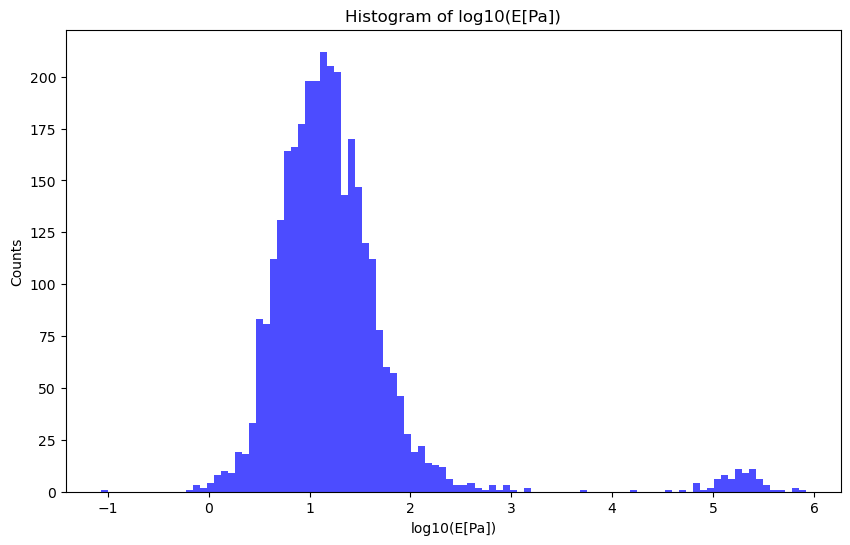

In [17]:
# plot using matplotlib without grid
plt.figure(figsize=(10, 6))
plt.hist(df['log10_E[Pa]'].dropna(), bins=100, color='blue', alpha=0.7)
plt.title('Histogram of log10(E[Pa])')
plt.xlabel('log10(E[Pa])')
# plt.xlim(left=0, right=9)
plt.ylabel('Counts')
plt.show()
